In [1]:
%pip install pandas
%pip install matplotlib
import pandas as pd
import re
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# use sep=';' for CSV files with semicolon delimiter
df = pd.read_csv('hacktivist_messages.csv', sep=';')

In [3]:
# Lowercase all Text
df['Text'] = df['Text'].str.lower()
# Remove \n and \r
df['Text'] = df['Text'].str.replace(r'[\n\r]', ' ', regex=True)

From taking sample of the data, I assume that first matching flag is usually country of interest.   
Therefor I will firstly catch those rows.   
If no success - I will try to catch text-strings containing country name - again first match is usually the interest


### A. EU and Nordic countries being attacked

In [4]:
FLAG_TEXT_TO_COUNTRY = {
    # Flags
    "🇩🇰": "Denmark",
    "🇫🇮": "Finland",
    "🇮🇸": "Iceland",
    "🇳🇴": "Norway",
    "🇸🇪": "Sweden",
    "🇦🇽": "Åland Islands",
    "🇫🇴": "Faroe Islands",
    "🇬🇱": "Greenland",
    "🇦🇹": "Austria",
    "🇧🇪": "Belgium",
    "🇧🇬": "Bulgaria",
    "🇭🇷": "Croatia",
    "🇨🇾": "Cyprus",
    "🇨🇿": "Czechia",
    "🇪🇪": "Estonia",
    "🇫🇷": "France",
    "🇩🇪": "Germany",
    "🇬🇷": "Greece",
    "🇭🇺": "Hungary",
    "🇮🇪": "Ireland",
    "🇮🇹": "Italy",
    "🇱🇻": "Latvia",
    "🇱🇹": "Lithuania",
    "🇱🇺": "Luxembourg",
    "🇲🇹": "Malta",
    "🇳🇱": "Netherlands",
    "🇵🇱": "Poland",
    "🇵🇹": "Portugal",
    "🇷🇴": "Romania",
    "🇸🇰": "Slovakia",
    "🇸🇮": "Slovenia",
    "🇪🇸": "Spain",
    "🇺🇦": "Ukraine",

    "danmark": "Denmark",        # danish, denmark
    "danish": "Denmark",  
    "finn": "Finland",       # finnish
    "iceland": "Iceland",        # icelandic
    "norw": "Norway",        # norwegian
    "swed": "Sweden",        # swedish
    "aland": "Åland Islands",
    "faroe": "Faroe Islands",
    "greenland": "Greenland",
    "austr": "Austria",      # austrian
    "belgar": "Belgium",       # belgian
    "bulgar": "Bulgaria",    # bulgarian
    "croat": "Croatia",      # croatian
    "cypr": "Cyprus",        # cypriot
    "czech": "Czechia",
    "eston": "Estonia",      # estonian
    "franc": "France",       # french
    "french": "France",
    "german": "Germany",       # german
    "greek": "Greece",
    "hungar": "Hungary",     # hungarian
    "ireland": "Ireland",        # irish
    "ital": "Italy",         # italian
    "latv": "Latvia",        # latvian
    "lithuan": "Lithuania",  # lithuanian
    "luxemburg": "Luxembourg",
    "malt": "Malta",
    "dutch": "Netherlands",
    "neth": "Netherlands",
    "poland": "Poland",         # polish
    "polish": "Poland",
    "polskie": "Poland",
    "portug": "Portugal",    # portuguese
    "romani": "Romania",      # romanian
    "slovak": "Slovakia",
    "sloven": "Slovenia",
    "span": "Spain",         # spanish
    "ukrain": "Ukraine",
    "europ": "European Union"
}

FLAG_RE = re.compile(r'[\U0001F1E6-\U0001F1FF]{2}')

def detect_country_from_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    
    lowered = text.lower()

    # 1. Try flag
    for match in FLAG_RE.finditer(text):
        flag = match.group()
        if flag in FLAG_TEXT_TO_COUNTRY:
            return FLAG_TEXT_TO_COUNTRY[flag]

    # 2. Try keyword (substring match)
    for keyword, country in FLAG_TEXT_TO_COUNTRY.items():
        if keyword == country:
            continue  # skip literal full names
        if keyword in lowered:
            return country

    return ''

In [5]:
df['First_flag_country'] = df['Text'].apply(detect_country_from_text)

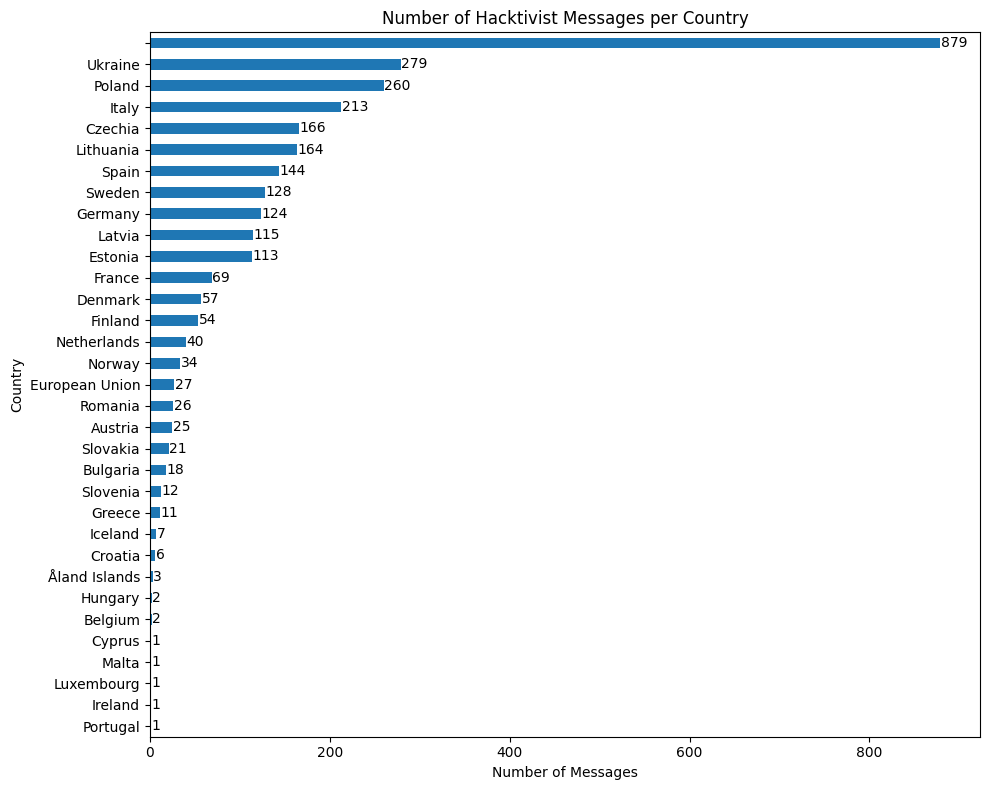

In [6]:
# Sort counts in ascending order
country_counts = df['First_flag_country'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
ax = country_counts.plot(kind='barh')  # horizontal bar chart

# Add count labels to each bar
for i, (value, count) in enumerate(country_counts.items()):
    ax.text(count + 0.5, i, str(count), va='center')

plt.xlabel('Number of Messages')
plt.ylabel('Country')
plt.title('Number of Hacktivist Messages per Country')
plt.tight_layout()
plt.show()

In [7]:
# Save as excel
df.to_excel('no_flag.xlsx', index=False)

In [8]:
df

,Message Id,Datetime,Text,First_flag_country
0,1,2022-08-10 17:58:53,look what we've found👨🏻‍💻 a well-known osint r...,
1,2,2022-08-11 20:01:02,hello comrades!👨🏻‍💻today we are back in poland...,Poland
2,3,2022-08-11 20:19:54,we've dropped the website of the chairman of t...,Latvia
3,4,2022-08-11 22:06:32,"friends, for the sake of interest, we decided...",Lithuania
4,5,2022-08-12 14:19:50,hello friends!👨🏻‍💻 we continue to bother latv...,Latvia
...,...,...,...,...
2999,3000,2024-08-19 12:45:27,NaN,
3000,3001,2024-08-19 13:45:20,continuing our stroll through ukrainian websit...,Ukraine
3001,3002,2024-08-19 15:59:43,we continue our cyberattack on zelensky's crim...,
3002,3003,2024-08-19 16:20:50,passed along with the cyberarmy of russia defe...,Ukraine


### B. Which critical infrastructure sectors 

In [31]:
import re

SECTOR_REGEX = {
    "Energy sector": re.compile(
        r"(power plant|power station|substation|electricity|wind farm|solar|photovoltaic|hydroelectric|geothermal|battery|transformer|grid operator|tso|dso)"
    ),
    "Transport sector": re.compile(
        r"(airport|runway|railway|railroad|train|metro|subway|tram|seaport|harbor|harbour|logistics|freight|highway|toll)"
    ),
    "Banking sector": re.compile(
        r"(bank|banking|iban|swift|bic|mortgage|loan|lending|deposit)"
    ),
    "Financial market infrastructure sector": re.compile(
        r"(exchange|trading|clearing|ccp|csd|settlement)"
    ),
    "Health sector": re.compile(
        r"(hospital|clinic|healthcare|pharmacy|ambulance|vaccine|laboratory|lab|radiology|pharma)"
    ),
    "Drinking water sector": re.compile(
        r"(drinking water|water supply|waterworks|treatment plant|desalination|reservoir|potable)"
    ),
    "Waste water sector": re.compile(
        r"(wastewater|waste water|sewage|sewer|effluent)"
    ),
    "Digital infrastructure sector": re.compile(
        r"(internet exchange|ixp|data center|data centre|colocation|dns|tld|registry|cloud|cdn|backbone|peering|bgp)"
    ),
    "Public administration sector": re.compile(
        r"(ministry|municipality|city hall|town hall|government|tax authority|customs|police|court|public administration)"
    ),
    "Space sector": re.compile(
        r"(satellite|earth station|mission control|spaceport|tt&c)"
    ),
    "Production, processing and distribution of food sector,": re.compile(
        r"(slaughterhouse|abattoir|meat|dairy|cheese|grain|flour|fish|bottling|food|cold storage)"
    ),
}

def detect_sectors(text: str):
    if not isinstance(text, str) or not text:
        return ''
    for sector, regex in SECTOR_REGEX.items():
        if regex.search(text):
            return sector
    return ''

In [32]:
df['sectors'] = df['Text'].apply(detect_sectors)
df

,Message Id,Datetime,Text,First_flag_country,sectors
0,1,2022-08-10 17:58:53,look what we've found👨🏻‍💻 a well-known osint r...,,
1,2,2022-08-11 20:01:02,hello comrades!👨🏻‍💻today we are back in poland...,Poland,Public administration sector
2,3,2022-08-11 20:19:54,we've dropped the website of the chairman of t...,Latvia,
3,4,2022-08-11 22:06:32,"friends, for the sake of interest, we decided...",Lithuania,Digital infrastructure sector
4,5,2022-08-12 14:19:50,hello friends!👨🏻‍💻 we continue to bother latv...,Latvia,
...,...,...,...,...,...
2999,3000,2024-08-19 12:45:27,NaN,,
3000,3001,2024-08-19 13:45:20,continuing our stroll through ukrainian websit...,Ukraine,
3001,3002,2024-08-19 15:59:43,we continue our cyberattack on zelensky's crim...,,
3002,3003,2024-08-19 16:20:50,passed along with the cyberarmy of russia defe...,Ukraine,


In [33]:
#make a df where only rows where sector is not empty list are kept
df_sectors = df[df['sectors'].map(len) > 0].copy()
df_sectors


,Message Id,Datetime,Text,First_flag_country,sectors
1,2,2022-08-11 20:01:02,hello comrades!👨🏻‍💻today we are back in poland...,Poland,Public administration sector
3,4,2022-08-11 22:06:32,"friends, for the sake of interest, we decided...",Lithuania,Digital infrastructure sector
5,6,2022-08-13 11:18:20,we visited poland🇵🇱 and killed the website of ...,Poland,Public administration sector
6,7,2022-08-13 13:54:16,we return to poland🇵🇱 and kill the site of ano...,Poland,Public administration sector
10,11,2022-08-15 08:26:15,the website of the association of non-banking ...,Latvia,Banking sector
...,...,...,...,...,...
2984,2985,2024-08-16 17:51:36,radware: pro-russian hacktivist group noname05...,Ukraine,Public administration sector
2986,2987,2024-08-17 09:49:02,we continue together with our colleagues to ni...,Ukraine,Transport sector
2987,2988,2024-08-17 10:46:31,continues sending ddos missiles to ukrainian s...,Ukraine,Public administration sector
2990,2991,2024-08-17 13:59:43,a bit “down” after our attacks sites of the uk...,Italy,Public administration sector


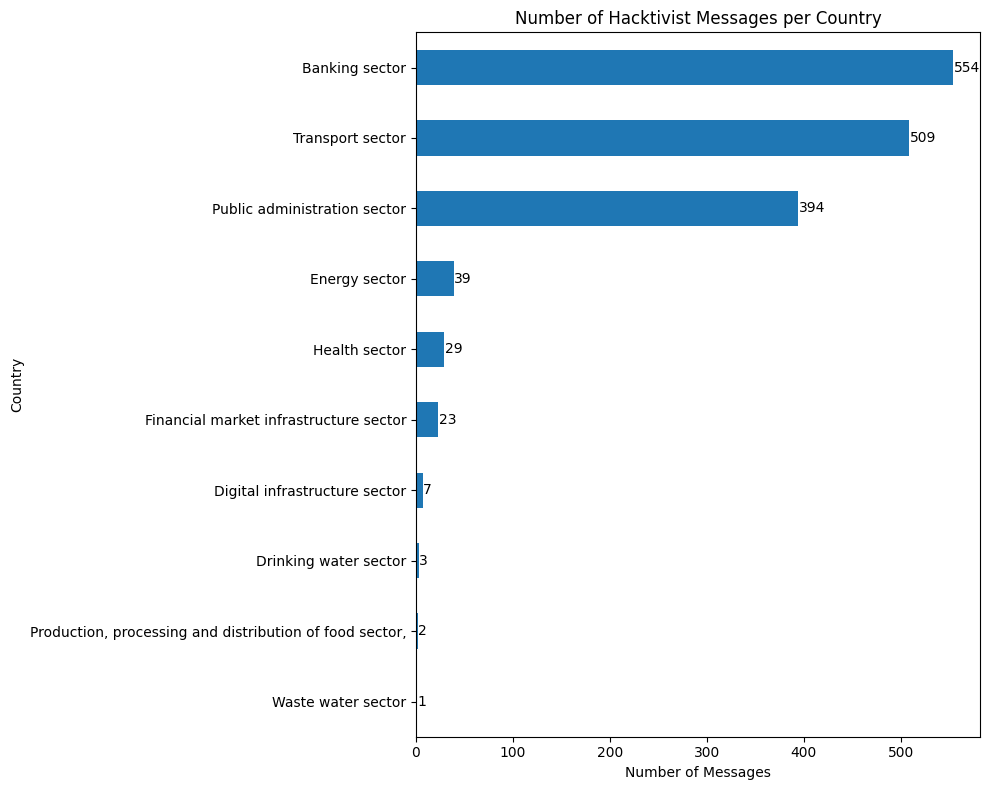

In [ ]:
sector_counts = df_sectors['sectors'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
ax = sector_counts.plot(kind='barh')  

# Add count labels to each bar
for i, (value, count) in enumerate(sector_counts.items()):
    ax.text(count + 0.5, i, str(count), va='center')

plt.xlabel('Number of Messages')
plt.ylabel('Country')
plt.title('Number of Hacktivist Messages per Country')
plt.tight_layout()
plt.show()

In [35]:
# print all unique sectors found
print(df_sectors['sectors'].unique())

['Public administration sector' 'Digital infrastructure sector'
 'Banking sector' 'Health sector' 'Transport sector' 'Energy sector'
 'Financial market infrastructure sector'
 'Production, processing and distribution of food sector,'
 'Waste water sector' 'Drinking water sector']


# C. Which security properties (confidentiality, integrity, availability) have been targetted?